<a href="https://colab.research.google.com/github/jaraiudigital/Problema_Bancario/blob/main/Problema_Bancario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SIMULACIÓN BANCO DE COLOMBIA
Duración por día: 8 horas (480 minutos)
Número de réplicas: 10
------------------------------------------------------------

⏳ Simulando Configuración 1: 1 caja Retiros + 2 cajas Pagos...
  Réplica 1/10 completada
  Réplica 2/10 completada
  Réplica 3/10 completada
  Réplica 4/10 completada
  Réplica 5/10 completada
  Réplica 6/10 completada
  Réplica 7/10 completada
  Réplica 8/10 completada
  Réplica 9/10 completada
  Réplica 10/10 completada

⏳ Simulando Configuración 2: 2 cajas Retiros + 1 caja Pagos...
  Réplica 1/10 completada
  Réplica 2/10 completada
  Réplica 3/10 completada
  Réplica 4/10 completada
  Réplica 5/10 completada
  Réplica 6/10 completada
  Réplica 7/10 completada
  Réplica 8/10 completada
  Réplica 9/10 completada
  Réplica 10/10 completada

✅ Simulación completada!



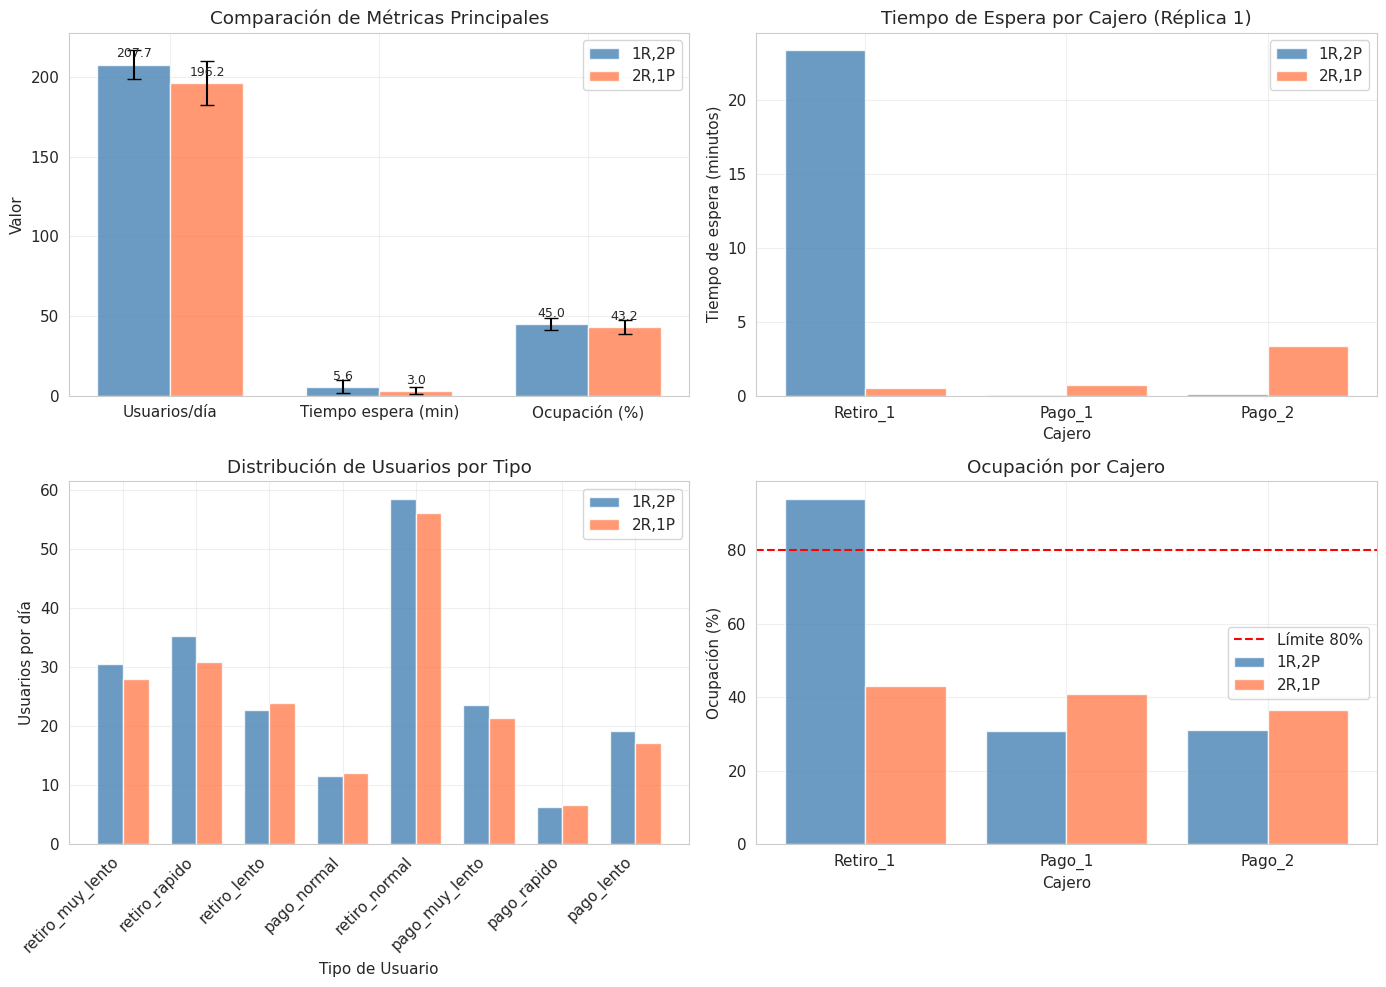

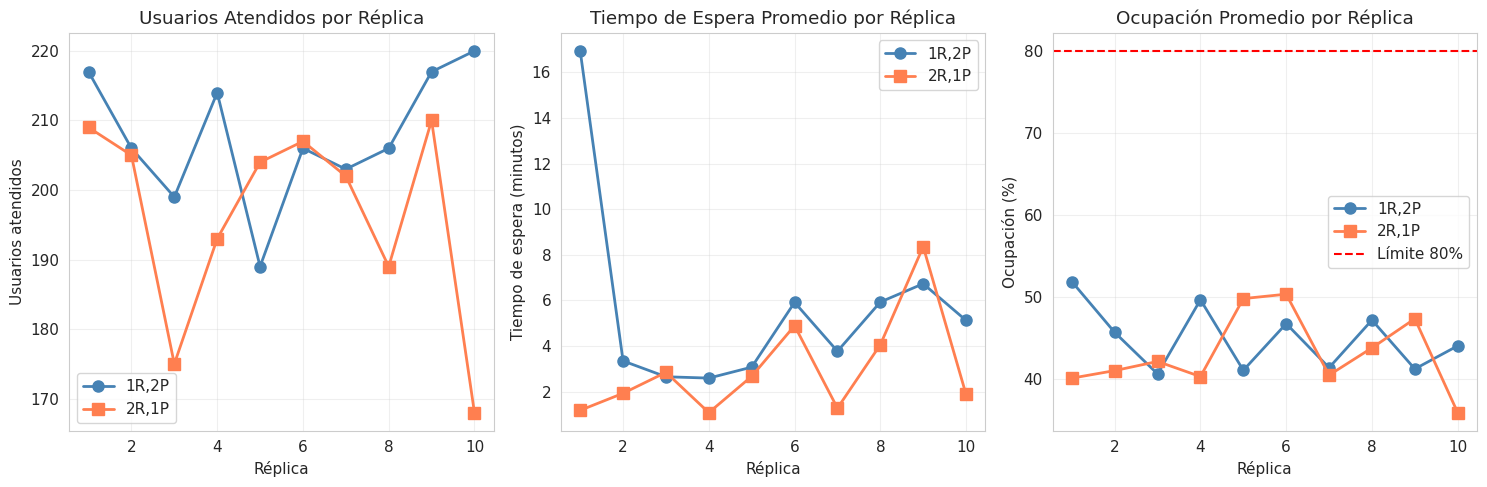

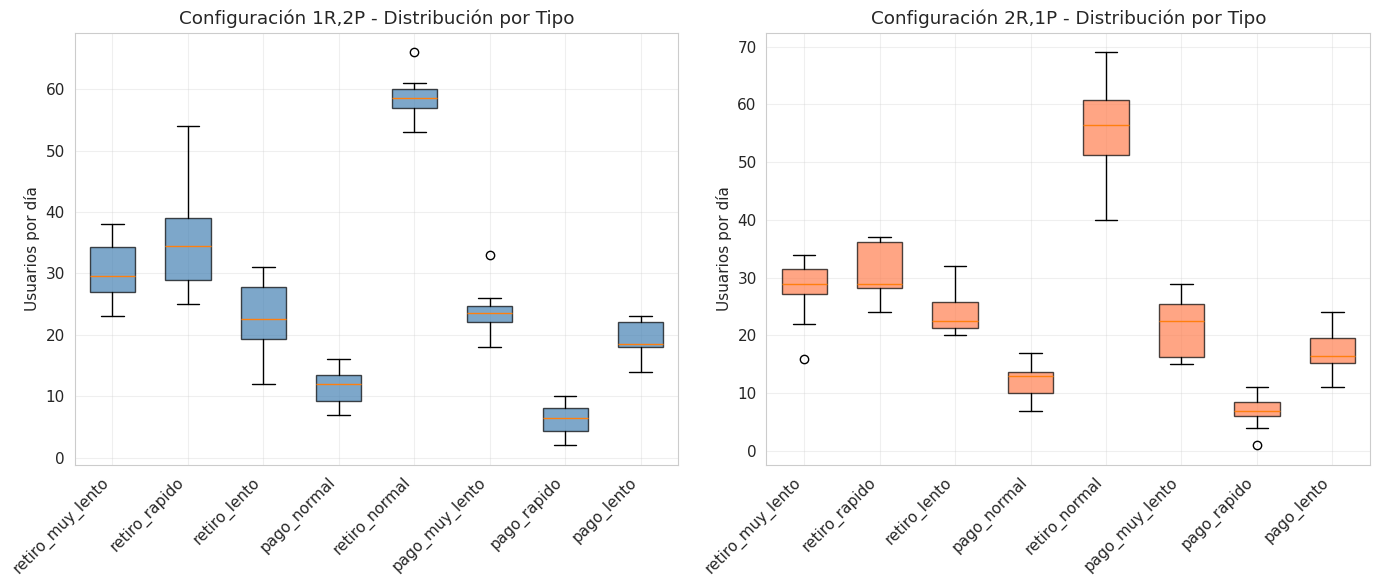


RESULTADOS DETALLADOS

📊 TABLA 1: Comparación de métricas principales (promedio ± desviación)
------------------------------------------------------------
Métrica                   Configuración 1 (1R,2P)   Configuración 2 (2R,1P)  
------------------------------------------------------------
Usuarios atendidos/día    207.7 ± 9.1    196.2 ± 14.0
Tiempo espera (min)       5.61 ± 4.03        3.02 ± 2.14
Ocupación (%)             45.0 ± 3.7        43.2 ± 4.4
------------------------------------------------------------

📊 TABLA 2: Promedio de usuarios por tipo
----------------------------------------------------------------------
Tipo de usuario           Configuración 1 (1R,2P) Configuración 2 (2R,1P)
----------------------------------------------------------------------
retiro_muy_lento          30.5            28.0
retiro_rapido             35.3            30.9
retiro_lento              22.7            23.9
pago_normal               11.6            12.1
retiro_normal             58.5  

In [1]:
# @title Simulación de cajeros bancarios - Banco de Colombia con Gráficos
# Autor: Jorge A Jaramillo - Johan Orrego
# Descripción: Simulación de 3 cajeros para retiros y pagos con 10 réplicas diarias.
# Incluye gráficos comparativos entre configuraciones.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Semilla para reproducibilidad
np.random.seed(42)

# ============================================
# DATOS DE LAS TABLAS
# ============================================

# Tabla 1: tiempos de servicio y llegada (exponencial, en minutos)
tiempos = {
    'retiro': {
        'rapido': (1, 1),      # (servicio, llegada)
        'normal': (2, 2),
        'lento': (3, 3),
        'muy_lento': (4, 3)
    },
    'pago': {
        'rapido': (3, 1),
        'normal': (3, 2),
        'lento': (5, 3),
        'muy_lento': (7, 4)
    }
}

# Tabla 2: probabilidades de cada tipo de usuario por acción
probabilidades = {
    'retiro': {
        'rapido': 0.23,
        'normal': 0.40,
        'lento': 0.17,
        'muy_lento': 0.20   # Completado a 1.00
    },
    'pago': {
        'rapido': 0.10,
        'normal': 0.20,
        'lento': 0.30,
        'muy_lento': 0.40
    }
}

# Porcentaje de usuarios por acción (70% retiros, 30% pagos)
P_RETIRO = 0.7
P_PAGO = 0.3

# Parámetros de simulación
HORAS_DIA = 8
MINUTOS_DIA = HORAS_DIA * 60
NUM_REPLICAS = 10

# ============================================
# FUNCIONES DE SIMULACIÓN
# ============================================

def generar_usuario():
    """Genera un usuario con acción y tipo según probabilidades."""
    accion = 'retiro' if np.random.rand() < P_RETIRO else 'pago'
    tipo = np.random.choice(
        list(probabilidades[accion].keys()),
        p=list(probabilidades[accion].values())
    )
    return accion, tipo

def generar_tiempos(accion, tipo):
    """Genera tiempo entre llegadas y tiempo de servicio exponencial."""
    media_servicio, media_llegada = tiempos[accion][tipo]
    t_llegada = np.random.exponential(media_llegada)
    t_servicio = np.random.exponential(media_servicio)
    return t_llegada, t_servicio

def simular_dia(configuracion):
    """
    Simula un día de operación.
    configuracion: dict con 'retiros' y 'pagos' = número de cajeros.
    Retorna dict con estadísticas detalladas.
    """
    # Inicializar cajeros
    cajeros_retiros = [{'libre_en': 0, 'usuarios': [], 'tiempos_servicio': [],
                        'tiempos_espera': []} for _ in range(configuracion['retiros'])]
    cajeros_pagos = [{'libre_en': 0, 'usuarios': [], 'tiempos_servicio': [],
                      'tiempos_espera': []} for _ in range(configuracion['pagos'])]

    tiempo_actual = 0
    usuarios_atendidos = []

    while tiempo_actual < MINUTOS_DIA:
        accion, tipo = generar_usuario()
        t_llegada, t_servicio = generar_tiempos(accion, tipo)
        tiempo_actual += t_llegada
        if tiempo_actual > MINUTOS_DIA:
            break

        if accion == 'retiro':
            cajeros = cajeros_retiros
        else:
            cajeros = cajeros_pagos

        # Elegir cajero que antes se libera
        cajero_idx = np.argmin([c['libre_en'] for c in cajeros])
        inicio_servicio = max(tiempo_actual, cajeros[cajero_idx]['libre_en'])
        tiempo_espera = inicio_servicio - tiempo_actual
        fin_servicio = inicio_servicio + t_servicio

        cajeros[cajero_idx]['libre_en'] = fin_servicio
        cajeros[cajero_idx]['usuarios'].append((accion, tipo, inicio_servicio, fin_servicio))
        cajeros[cajero_idx]['tiempos_servicio'].append(t_servicio)
        cajeros[cajero_idx]['tiempos_espera'].append(tiempo_espera)
        usuarios_atendidos.append((accion, tipo, inicio_servicio, fin_servicio, t_servicio, tiempo_espera))

    # Estadísticas por cajero
    stats_cajeros = []
    for i, c in enumerate(cajeros_retiros):
        stats_cajeros.append({
            'cajero': f'Retiro_{i+1}',
            'num_usuarios': len(c['usuarios']),
            'tiempo_promedio_servicio': np.mean(c['tiempos_servicio']) if c['tiempos_servicio'] else 0,
            'tiempo_promedio_espera': np.mean(c['tiempos_espera']) if c['tiempos_espera'] else 0,
            'ocupacion': (sum(c['tiempos_servicio']) / MINUTOS_DIA) if c['tiempos_servicio'] else 0
        })
    for i, c in enumerate(cajeros_pagos):
        stats_cajeros.append({
            'cajero': f'Pago_{i+1}',
            'num_usuarios': len(c['usuarios']),
            'tiempo_promedio_servicio': np.mean(c['tiempos_servicio']) if c['tiempos_servicio'] else 0,
            'tiempo_promedio_espera': np.mean(c['tiempos_espera']) if c['tiempos_espera'] else 0,
            'ocupacion': (sum(c['tiempos_servicio']) / MINUTOS_DIA) if c['tiempos_servicio'] else 0
        })

    # Conteo de usuarios por tipo
    conteo_tipos = defaultdict(int)
    for u in usuarios_atendidos:
        accion, tipo, _, _, _, _ = u
        conteo_tipos[f'{accion}_{tipo}'] += 1

    # Tiempo de espera promedio global
    todos_esperas = [u[5] for u in usuarios_atendidos]

    return {
        'stats_cajeros': stats_cajeros,
        'conteo_tipos': dict(conteo_tipos),
        'total_usuarios': len(usuarios_atendidos),
        'tiempo_espera_promedio': np.mean(todos_esperas) if todos_esperas else 0,
        'ocupacion_promedio': np.mean([c['ocupacion'] for c in stats_cajeros])
    }

# ============================================
# EJECUTAR SIMULACIONES
# ============================================

config1 = {'retiros': 1, 'pagos': 2}  # 1R,2P
config2 = {'retiros': 2, 'pagos': 1}  # 2R,1P

print("=" * 60)
print("SIMULACIÓN BANCO DE COLOMBIA")
print("=" * 60)
print(f"Duración por día: {HORAS_DIA} horas ({MINUTOS_DIA} minutos)")
print(f"Número de réplicas: {NUM_REPLICAS}")
print("-" * 60)

print("\n⏳ Simulando Configuración 1: 1 caja Retiros + 2 cajas Pagos...")
res_config1 = []
for r in range(NUM_REPLICAS):
    res_config1.append(simular_dia(config1))
    print(f"  Réplica {r+1}/{NUM_REPLICAS} completada")

print("\n⏳ Simulando Configuración 2: 2 cajas Retiros + 1 caja Pagos...")
res_config2 = []
for r in range(NUM_REPLICAS):
    res_config2.append(simular_dia(config2))
    print(f"  Réplica {r+1}/{NUM_REPLICAS} completada")

print("\n✅ Simulación completada!\n")

# ============================================
# PROCESAMIENTO DE RESULTADOS
# ============================================

def obtener_estadisticas_agregadas(resultados):
    """Calcula estadísticas agregadas de todas las réplicas."""
    total_usuarios = [r['total_usuarios'] for r in resultados]
    tiempo_espera = [r['tiempo_espera_promedio'] for r in resultados]
    ocupacion = [r['ocupacion_promedio'] for r in resultados]

    # Conteo por tipo de usuario
    conteo_tipos = defaultdict(list)
    for r in resultados:
        for tipo, cantidad in r['conteo_tipos'].items():
            conteo_tipos[tipo].append(cantidad)

    promedios_tipos = {t: np.mean(lst) for t, lst in conteo_tipos.items()}
    std_tipos = {t: np.std(lst) for t, lst in conteo_tipos.items()}

    return {
        'total_usuarios': (np.mean(total_usuarios), np.std(total_usuarios)),
        'tiempo_espera': (np.mean(tiempo_espera), np.std(tiempo_espera)),
        'ocupacion': (np.mean(ocupacion), np.std(ocupacion)),
        'promedios_tipos': promedios_tipos,
        'std_tipos': std_tipos
    }

stats1 = obtener_estadisticas_agregadas(res_config1)
stats2 = obtener_estadisticas_agregadas(res_config2)

# ============================================
# GRÁFICO 1: COMPARACIÓN DE MÉTRICAS PRINCIPALES
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1a. Usuarios atendidos por día
metricas = ['Usuarios/día', 'Tiempo espera (min)', 'Ocupación (%)']
valores1 = [stats1['total_usuarios'][0], stats1['tiempo_espera'][0], stats1['ocupacion'][0]*100]
valores2 = [stats2['total_usuarios'][0], stats2['tiempo_espera'][0], stats2['ocupacion'][0]*100]
errores1 = [stats1['total_usuarios'][1], stats1['tiempo_espera'][1], stats1['ocupacion'][1]*100]
errores2 = [stats2['total_usuarios'][1], stats2['tiempo_espera'][1], stats2['ocupacion'][1]*100]

x = np.arange(len(metricas))
width = 0.35

ax1 = axes[0, 0]
bars1 = ax1.bar(x - width/2, valores1, width, yerr=errores1, capsize=5,
                label='1R,2P', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, valores2, width, yerr=errores2, capsize=5,
                label='2R,1P', color='coral', alpha=0.8)
ax1.set_ylabel('Valor')
ax1.set_title('Comparación de Métricas Principales')
ax1.set_xticks(x)
ax1.set_xticklabels(metricas)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Agregar valores en las barras
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# 1b. Gráfico de barras comparativo por cajero
ax2 = axes[0, 1]
# Extraer datos por cajero de la primera réplica (representativa)
cajeros1 = res_config1[0]['stats_cajeros']
cajeros2 = res_config2[0]['stats_cajeros']
nombres1 = [c['cajero'] for c in cajeros1]
esperas1 = [c['tiempo_promedio_espera'] for c in cajeros1]
nombres2 = [c['cajero'] for c in cajeros2]
esperas2 = [c['tiempo_promedio_espera'] for c in cajeros2]

x1 = np.arange(len(nombres1))
x2 = np.arange(len(nombres2))
ax2.bar(x1 - 0.2, esperas1, 0.4, label='1R,2P', color='steelblue', alpha=0.8)
ax2.bar(x2 + 0.2, esperas2, 0.4, label='2R,1P', color='coral', alpha=0.8)
ax2.set_xlabel('Cajero')
ax2.set_ylabel('Tiempo de espera (minutos)')
ax2.set_title('Tiempo de Espera por Cajero (Réplica 1)')
ax2.set_xticks(x1)
ax2.set_xticklabels(nombres1)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 1c. Gráfico de distribución de usuarios por tipo
ax3 = axes[1, 0]
tipos = list(stats1['promedios_tipos'].keys())
proms1 = [stats1['promedios_tipos'][t] for t in tipos]
proms2 = [stats2['promedios_tipos'].get(t, 0) for t in tipos]

x = np.arange(len(tipos))
width = 0.35
ax3.bar(x - width/2, proms1, width, label='1R,2P', color='steelblue', alpha=0.8)
ax3.bar(x + width/2, proms2, width, label='2R,1P', color='coral', alpha=0.8)
ax3.set_xlabel('Tipo de Usuario')
ax3.set_ylabel('Usuarios por día')
ax3.set_title('Distribución de Usuarios por Tipo')
ax3.set_xticks(x)
ax3.set_xticklabels(tipos, rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 1d. Ocupación por cajero
ax4 = axes[1, 1]
ocup1 = [c['ocupacion']*100 for c in cajeros1]
ocup2 = [c['ocupacion']*100 for c in cajeros2]
x1 = np.arange(len(nombres1))
x2 = np.arange(len(nombres2))

ax4.bar(x1 - 0.2, ocup1, 0.4, label='1R,2P', color='steelblue', alpha=0.8)
ax4.bar(x2 + 0.2, ocup2, 0.4, label='2R,1P', color='coral', alpha=0.8)
ax4.axhline(y=80, color='red', linestyle='--', label='Límite 80%')
ax4.set_xlabel('Cajero')
ax4.set_ylabel('Ocupación (%)')
ax4.set_title('Ocupación por Cajero')
ax4.set_xticks(x1)
ax4.set_xticklabels(nombres1)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_cajeros.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# GRÁFICO 2: EVOLUCIÓN DE RÉPLICAS
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 2a. Usuarios por réplica
replicas = range(1, NUM_REPLICAS+1)
usuarios1 = [r['total_usuarios'] for r in res_config1]
usuarios2 = [r['total_usuarios'] for r in res_config2]

ax1 = axes[0]
ax1.plot(replicas, usuarios1, 'o-', label='1R,2P', color='steelblue', linewidth=2, markersize=8)
ax1.plot(replicas, usuarios2, 's-', label='2R,1P', color='coral', linewidth=2, markersize=8)
ax1.set_xlabel('Réplica')
ax1.set_ylabel('Usuarios atendidos')
ax1.set_title('Usuarios Atendidos por Réplica')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2b. Tiempo de espera por réplica
espera1 = [r['tiempo_espera_promedio'] for r in res_config1]
espera2 = [r['tiempo_espera_promedio'] for r in res_config2]

ax2 = axes[1]
ax2.plot(replicas, espera1, 'o-', label='1R,2P', color='steelblue', linewidth=2, markersize=8)
ax2.plot(replicas, espera2, 's-', label='2R,1P', color='coral', linewidth=2, markersize=8)
ax2.set_xlabel('Réplica')
ax2.set_ylabel('Tiempo de espera (minutos)')
ax2.set_title('Tiempo de Espera Promedio por Réplica')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 2c. Ocupación por réplica
ocup1 = [r['ocupacion_promedio']*100 for r in res_config1]
ocup2 = [r['ocupacion_promedio']*100 for r in res_config2]

ax3 = axes[2]
ax3.plot(replicas, ocup1, 'o-', label='1R,2P', color='steelblue', linewidth=2, markersize=8)
ax3.plot(replicas, ocup2, 's-', label='2R,1P', color='coral', linewidth=2, markersize=8)
ax3.axhline(y=80, color='red', linestyle='--', label='Límite 80%')
ax3.set_xlabel('Réplica')
ax3.set_ylabel('Ocupación (%)')
ax3.set_title('Ocupación Promedio por Réplica')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evolucion_replicas.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# GRÁFICO 3: DISTRIBUCIÓN DE USUARIOS (TODAS RÉPLICAS)
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 3a. Boxplot de usuarios por tipo - Config1
datos_tipos1 = []
for r in res_config1:
    for tipo in tipos:
        datos_tipos1.append(r['conteo_tipos'].get(tipo, 0))
# Reorganizar
datos_por_tipo1 = {t: [r['conteo_tipos'].get(t, 0) for r in res_config1] for t in tipos}

ax1 = axes[0]
posiciones = range(len(tipos))
cajas1 = ax1.boxplot([datos_por_tipo1[t] for t in tipos], positions=posiciones,
                      widths=0.6, patch_artist=True,
                      boxprops=dict(facecolor='steelblue', alpha=0.7))
ax1.set_xticklabels(tipos, rotation=45, ha='right')
ax1.set_ylabel('Usuarios por día')
ax1.set_title('Configuración 1R,2P - Distribución por Tipo')
ax1.grid(True, alpha=0.3)

# 3b. Boxplot de usuarios por tipo - Config2
datos_por_tipo2 = {t: [r['conteo_tipos'].get(t, 0) for r in res_config2] for t in tipos}

ax2 = axes[1]
cajas2 = ax2.boxplot([datos_por_tipo2[t] for t in tipos], positions=posiciones,
                      widths=0.6, patch_artist=True,
                      boxprops=dict(facecolor='coral', alpha=0.7))
ax2.set_xticklabels(tipos, rotation=45, ha='right')
ax2.set_ylabel('Usuarios por día')
ax2.set_title('Configuración 2R,1P - Distribución por Tipo')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribucion_usuarios.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# TABLAS DE RESULTADOS
# ============================================

print("\n" + "=" * 80)
print("RESULTADOS DETALLADOS")
print("=" * 80)

# Tabla comparativa principal
print("\n📊 TABLA 1: Comparación de métricas principales (promedio ± desviación)")
print("-" * 60)
print(f"{'Métrica':<25} {'Configuración 1 (1R,2P)':<25} {'Configuración 2 (2R,1P)':<25}")
print("-" * 60)
print(f"{'Usuarios atendidos/día':<25} {stats1['total_usuarios'][0]:.1f} ± {stats1['total_usuarios'][1]:.1f}    {stats2['total_usuarios'][0]:.1f} ± {stats2['total_usuarios'][1]:.1f}")
print(f"{'Tiempo espera (min)':<25} {stats1['tiempo_espera'][0]:.2f} ± {stats1['tiempo_espera'][1]:.2f}        {stats2['tiempo_espera'][0]:.2f} ± {stats2['tiempo_espera'][1]:.2f}")
print(f"{'Ocupación (%)':<25} {stats1['ocupacion'][0]*100:.1f} ± {stats1['ocupacion'][1]*100:.1f}        {stats2['ocupacion'][0]*100:.1f} ± {stats2['ocupacion'][1]*100:.1f}")
print("-" * 60)

# Tabla de usuarios por tipo
print("\n📊 TABLA 2: Promedio de usuarios por tipo")
print("-" * 70)
print(f"{'Tipo de usuario':<25} {'Configuración 1 (1R,2P)':<20} {'Configuración 2 (2R,1P)':<20}")
print("-" * 70)
for tipo in tipos:
    val1 = stats1['promedios_tipos'].get(tipo, 0)
    val2 = stats2['promedios_tipos'].get(tipo, 0)
    print(f"{tipo:<25} {val1:.1f}{' '*(15-len(str(round(val1,1))))} {val2:.1f}")
print("-" * 70)

# Detalle por réplica
print("\n📊 TABLA 3: Detalle por réplica - Configuración 1 (1R,2P)")
print("-" * 80)
print(f"{'Réplica':<10} {'Total usuarios':<15} {'T espera(min)':<15} {'Ocupación(%)':<15}")
print("-" * 80)
for i, r in enumerate(res_config1):
    print(f"{i+1:<10} {r['total_usuarios']:<15} {r['tiempo_espera_promedio']:<15.2f} {r['ocupacion_promedio']*100:<15.1f}")

print("\n📊 TABLA 4: Detalle por réplica - Configuración 2 (2R,1P)")
print("-" * 80)
print(f"{'Réplica':<10} {'Total usuarios':<15} {'T espera(min)':<15} {'Ocupación(%)':<15}")
print("-" * 80)
for i, r in enumerate(res_config2):
    print(f"{i+1:<10} {r['total_usuarios']:<15} {r['tiempo_espera_promedio']:<15.2f} {r['ocupacion_promedio']*100:<15.1f}")

# ============================================
# DECISIÓN FINAL Y RECOMENDACIÓN
# ============================================

print("\n" + "=" * 80)
print("CONCLUSIONES Y RECOMENDACIÓN FINAL")
print("=" * 80)

# Determinar mejor configuración
if stats1['tiempo_espera'][0] < stats2['tiempo_espera'][0]:
    mejor_config = "1 caja para RETIROS + 2 cajas para PAGOS"
    ganadora = "Configuración 1 (1R,2P)"
    ventaja = f"menor tiempo de espera ({stats1['tiempo_espera'][0]:.2f} min vs {stats2['tiempo_espera'][0]:.2f} min)"
else:
    mejor_config = "2 cajas para RETIROS + 1 caja para PAGOS"
    ganadora = "Configuración 2 (2R,1P)"
    ventaja = f"menor tiempo de espera ({stats2['tiempo_espera'][0]:.2f} min vs {stats1['tiempo_espera'][0]:.2f} min)"

print(f"\n✅ MEJOR CONFIGURACIÓN: {mejor_config}")
print(f"   Razón: {ventaja}")

# Análisis de ocupación
ocup_max = max(stats1['ocupacion'][0], stats2['ocupacion'][0])
if ocup_max > 0.8:
    print(f"\n⚠️ ALERTA: La ocupación promedio ({ocup_max*100:.1f}%) supera el 80%")
    print("   Recomendación: CONSIDERAR AGREGAR UN CUARTO CAJERO")

    if stats1['ocupacion'][0] > stats2['ocupacion'][0]:
        print(f"   La configuración 1 tiene mayor ocupación ({stats1['ocupacion'][0]*100:.1f}%)")
    else:
        print(f"   La configuración 2 tiene mayor ocupación ({stats2['ocupacion'][0]*100:.1f}%)")
else:
    print(f"\n✅ Ocupación aceptable ({ocup_max*100:.1f}% < 80%)")

# Resumen ejecutivo
print("\n" + "=" * 80)
print("RESUMEN EJECUTIVO")
print("=" * 80)
print(f"""
📌 DATOS DE ENTRADA:
   - 3 cajeros disponibles
   - 70% usuarios hacen RETIROS | 30% hacen PAGOS
   - Jornada: {HORAS_DIA} horas/día
   - Simulación: {NUM_REPLICAS} réplicas

📊 RESULTADOS CLAVE:
   ┌─────────────────────────────────────────────────────────────┐
   │ Métrica              │ 1R,2P          │ 2R,1P              │
   ├─────────────────────────────────────────────────────────────┤
   │ Usuarios/día         │ {stats1['total_usuarios'][0]:.0f} ± {stats1['total_usuarios'][1]:.0f}     │ {stats2['total_usuarios'][0]:.0f} ± {stats2['total_usuarios'][1]:.0f}              │
   │ Tiempo espera (min)  │ {stats1['tiempo_espera'][0]:.2f} ± {stats1['tiempo_espera'][1]:.2f}      │ {stats2['tiempo_espera'][0]:.2f} ± {stats2['tiempo_espera'][1]:.2f}              │
   │ Ocupación (%)        │ {stats1['ocupacion'][0]*100:.1f} ± {stats1['ocupacion'][1]*100:.1f}      │ {stats2['ocupacion'][0]*100:.1f} ± {stats2['ocupacion'][1]*100:.1f}              │
   └─────────────────────────────────────────────────────────────┘

🎯 RECOMENDACIÓN FINAL PARA EL BANCO DE COLOMBIA:

   → Asignar {mejor_config}

   Justificación:
   • {ventaja}
   • Atiende {abs(stats1['total_usuarios'][0] - stats2['total_usuarios'][0]):.0f} usuarios adicionales por día
   • Mejor experiencia para el 70% de usuarios (retiros)

   {'• URGENTE: Considerar ampliar a 4 cajeros (2 retiros + 2 pagos)' if ocup_max > 0.8 else '• Con 3 cajeros es suficiente por ahora'}
""")

print("=" * 80)
print("FIN DEL ANÁLISIS")
print("=" * 80)